In [2]:
"""
# Dylan's R Code
n_samples <- 1000
p <- rep( NA , n_samples )
p[1] <- 0.5
W <- 6
L <- 3
for ( i in 2:n_samples ) {
  p_new <- rnorm( 1 , p[i-1] , 0.1 )      
  if ( p_new < 0 ) p_new <- abs( p_new )
  if ( p_new > 1 ) p_new <- 2 - p_new
  q0 <- dbinom( W , W+L , p[i-1] )        
  q1 <- dbinom( W , W+L , p_new )
  p[i] <- ifelse( runif(1) < q1/q0 , p_new , p[i-1] )
}
dens( p , xlim=c(0,1) )
curve( dbeta( x , W+1 , L+1 ) , lty=2 , add=TRUE )
"""

"\n# Dylan's R Code\nn_samples <- 1000\np <- rep( NA , n_samples )\np[1] <- 0.5\nW <- 6\nL <- 3\nfor ( i in 2:n_samples ) {\n  p_new <- rnorm( 1 , p[i-1] , 0.1 )      \n  if ( p_new < 0 ) p_new <- abs( p_new )\n  if ( p_new > 1 ) p_new <- 2 - p_new\n  q0 <- dbinom( W , W+L , p[i-1] )        \n  q1 <- dbinom( W , W+L , p_new )\n  p[i] <- ifelse( runif(1) < q1/q0 , p_new , p[i-1] )\n}\ndens( p , xlim=c(0,1) )\ncurve( dbeta( x , W+1 , L+1 ) , lty=2 , add=TRUE )\n"

In [8]:
import pandas as pd
# Module for the probability distributions
import numpy as np
# Module for plotting graphs
import matplotlib.pyplot as plt
# Module used for computing the acceptance probability + beta function + kernel-density estimate
from scipy.stats import binom, beta, gaussian_kde

def likelihood(W, L, p): 
    return p**W * (1 - p)**L # returns likelihood of Ws and Ls observed if assumed p is true

# rewrite as reusable function with optional arguments
def MH_binomial(target_dist, n_samples, proposal_std, initial_state, random_seed = None, plot = True, prob_threshold = None):

    # set seed if optional argument is used
    rng = np.random.default_rng(random_seed)

    samples = np.zeros(n_samples) # Vector to store each sample
    samples[0] = initial_state  # set starting point in chain
    accepted = 0 # initialize number of accepted candidates 

    for i in range(1, n_samples):
        current = samples[i-1] # samples [i- 1] is current state (estimate of parameter)
        proposal = rng.normal(current, proposal_std) # proposal distribution for generating candidiates

        # reflect to keep p in [0, 1]
        if proposal < 0:
            proposal = -proposal
        if proposal > 1:
            proposal = 2 - proposal

        q0 = target_dist(W, L, current) # likelihood of current parameter value
        q1 = target_dist(W, L, proposal) # likelihood of proposed parameter value

        # detemine acceptance ratio
        acceptance_ratio = q1 / q0 if q0 != 0 else 1 # avoid division by 0 errors
        accept_prob = min(1, acceptance_ratio)

        # determine if we accept or reject candidtate from proposal
        if rng.uniform() < accept_prob:
            samples[i] = proposal
            accepted += 1
        else:
            samples[i] = current

    # Plot results
    if plot: 
        x = np.linspace(0, 1, 200) # 200 tick marks between a and b
        kde = gaussian_kde(samples) # gaussian kernel density estimation, smoothes spikes into softer curve
        plt.plot(x, kde(x), label="MH Density Estimate") 
        plt.plot(x, beta.pdf(x, W + 1, L + 1), 'r--', label="Beta Posterior") # beta pdf with shape parameters W+1 and L+1
        plt.xlim(0,1)
        plt.xlabel("p") 
        plt.ylabel("Density")
        plt.legend()
        plt.title(f"MH Density Estimate")
        plt.show()

    # MC estimators
    posterior_mean = samples.mean() # estimated value of p
    posterior_variance = samples.var() # tells us about uncertainty of estimation
    prob_above = None
    if prob_threshold is not None:
        samples_above_t = (samples > prob_threshold) # list of booleans
        prob_above_t = samples_above_t.mean() # average 1s and 0s
    
    # acceptance rate
    acceptance_rate = accepted / (n_samples - 1) # don't divide by n_samples bc samples[0] was initial guess rather than a candidate
    
    # convert samples fom array to dataframe
    samples_df = pd.DataFrame(samples, columns = ["Samples"])

    # organize results in dictionary for better printed view
    results = {
        'acceptance_rate': acceptance_rate,
        'samples': samples_df,
        'posterior_mean': posterior_mean,
        'posterior_variance': posterior_variance
    }

    # if given argument for prob_threshold, add entry to dictionary
    if prob_threshold is not None:
        results['prob_above_threshold'] = prob_above_t
        
    return results

# sample p from posterior and compute probability that W_new # of Ws are observed given that p
# don't use likelihood bc the binomial coefficent does not cancel in MC estimate
def posterior_predictive_prob(W_new, n_new, p_samples):
    probs = binom.pmf(W_new, n_new, p_samples) # P( W_new | p_i) for each p_sample (posterior draw)
    return np.mean(probs) # MC estimate of P( W_new | posterior data )

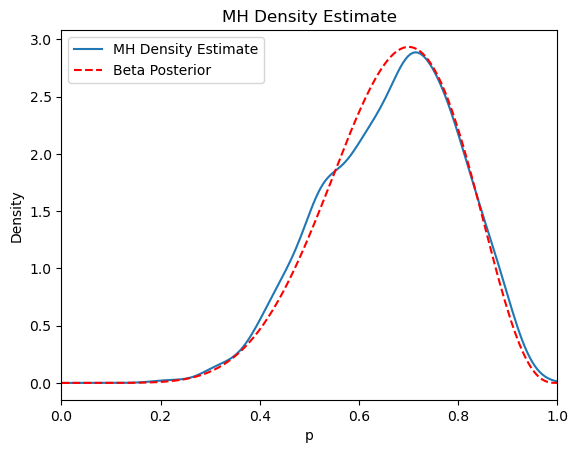

Posterior mean :  0.6650

Posterior variance :  0.0179

Acceptance rate :  0.5015

P( p > 0.6 | W = 7, L = 3) :  0.6970

Samples :
      Samples
0    0.500000
1    0.581586
2    0.769731
3    0.566039
4    0.566039
..        ...
995  0.768215
996  0.734099
997  0.734099
998  0.673123
999  0.673123

[1000 rows x 1 columns]

Posterior predictive probablity, P(W_new = 3 | posterior data) :  0.2728


In [14]:
# observed data 
W, L = 7, 3

# set arguments for MH_binomial
t = 0.6 # need stated for print statement
results = MH_binomial(target_dist = likelihood, n_samples = 1000, proposal_std = 0.45, initial_state = 0.5, random_seed = 3, prob_threshold = t)

print(f"Posterior mean : {results["posterior_mean"] : .4f}\n")
print(f"Posterior variance : {results["posterior_variance"] : 0.4f}\n")
print(f"Acceptance rate : {results["acceptance_rate"] : .4f}\n")

if "prob_above_threshold" in results:
   print(f"P( p > {t} | W = {W}, L = {L}) : {results["prob_above_threshold"] : .4f}\n")

print(f"Samples :\n{results["samples"]}\n")
samples = results["samples"] 

W_new = 3
pp_prob = posterior_predictive_prob(W_new, n_new = 5, p_samples = samples)
print(f"Posterior predictive probablity, P(W_new = {W_new} | posterior data) : {pp_prob : .4f}")

In [13]:
# target distribution is binomial posterior with two parameters W and L, unormalized target distribution is likelihood function 
# proposal distribution is normal distribution centered at current state with variance of proposal_std^2

# likelihood function : likelihood of observing the W/L data assuming p value; P( W, L | p )
# posterior_mean : estimated value of p given the data; E[ p | W, L ]
# posterior_variance : measure of uncertanity of estimate
# prob_threshold : given W/L data, how confident are we that p is at least the threshold; P( p > prob_threshold | W, L )
# posterior_predictive_prob : probability of observeing new Ws in more trials given estimated p; P( W_new | posterior data)

In [ ]:
# need to address burn-in/warm-up
# simulate full posterior predictive prob distribution and plot with histogram